# 03 - Mapa e Visualizações de Mobilidade Urbana

Gera o mapa coroplético dos bairros de Recife colorido pela nota de mobilidade,
e visualizações finais para o dashboard.

**Coroplético** = mapa em que cada região é colorida conforme um valor numérico (como um mapa de calor por bairro).

In [12]:
import pandas as pd
import geopandas as gpd
import folium
import plotly.express as px
import plotly.graph_objects as go
import json
import os
from pathlib import Path
from IPython.display import display, IFrame
import matplotlib.pyplot as plt
import matplotlib.colors as mcolors

In [13]:
# Localiza a raiz do projeto
def find_root():
    for p in [Path.cwd(), *Path.cwd().parents]:
        if (p / '.git').exists():
            return p
    return Path.cwd()

ROOT = find_root()
GEO_PATH = ROOT / 'data' / 'processed' / 'recife_mobilidade.geojson'
CSV_PATH = ROOT / 'data' / 'processed' / 'mobilidade_por_bairro.csv'

print(f'ROOT: {ROOT}')
print(f'GeoJSON: {GEO_PATH} | existe: {GEO_PATH.exists()}')

ROOT: C:\Users\Adriana\IVU-Recife
GeoJSON: C:\Users\Adriana\IVU-Recife\data\processed\recife_mobilidade.geojson | existe: True


In [14]:
# Carrega os dados de mobilidade processados
gdf = gpd.read_file(GEO_PATH)
print(f'Bairros carregados: {len(gdf)}')
print('Colunas:', gdf.columns.tolist())
display(gdf.head(3))

# Identifica a coluna com o NOME do bairro (prefere NM_ sobre CD_)
col_bairro = None
for col in gdf.columns:
    if col.upper().startswith('NM_') and 'BAIRRO' in col.upper():
        col_bairro = col
        break
if col_bairro is None:
    for col in gdf.columns:
        if 'bairro' in col.lower():
            col_bairro = col
            break

# Garante que a coluna é string e sem nulos
gdf = gdf.dropna(subset=[col_bairro]).copy()
gdf[col_bairro] = gdf[col_bairro].astype(str)

print(f'\nColuna de bairro: "{col_bairro}"')
print(f'Bairros válidos: {len(gdf)}')

Bairros carregados: 2835
Colunas: ['CD_BAIRRO', 'num_paradas', 'area_km2', 'densidade_paradas', 'nota_mobilidade', 'geometry']


,CD_BAIRRO,num_paradas,area_km2,densidade_paradas,nota_mobilidade,geometry
0,2611606003,62,0.054243,1143.014459,0.15,"POLYGON ((-34.88768 -8.06219, -34.88783 -8.062..."
1,2611606003,62,0.105744,586.319775,0.08,"POLYGON ((-34.88701 -8.06055, -34.88671 -8.060..."
2,2611606003,62,0.056502,1097.299553,0.14,"POLYGON ((-34.8858 -8.0599, -34.88443 -8.06056..."



Coluna de bairro: "CD_BAIRRO"
Bairros válidos: 2834


Mapa salvo em: C:\Users\Adriana\IVU-Recife\data\final\mapa_mobilidade.png


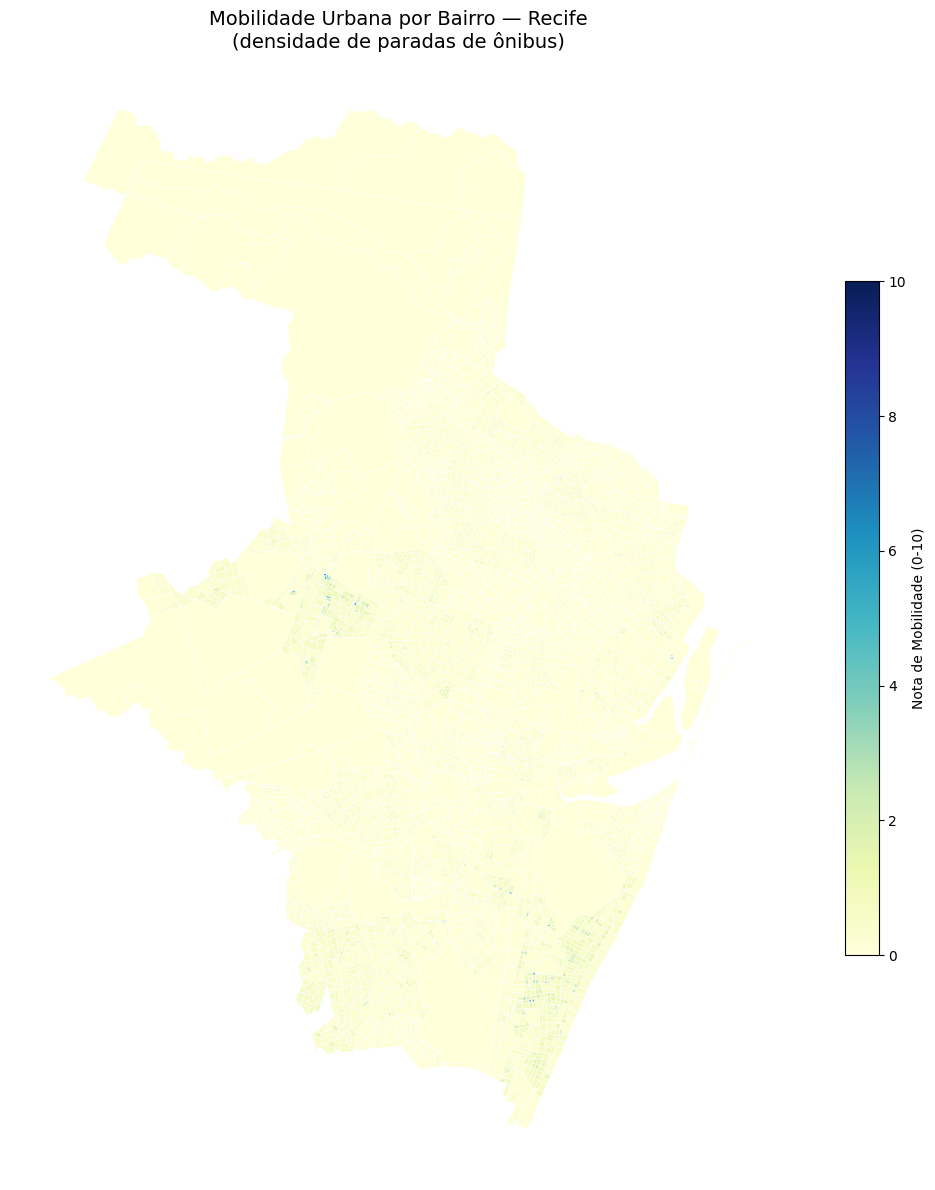

In [15]:
# ── MAPA ESTÁTICO (matplotlib) ──────────────────────────────────────────────
fig, ax = plt.subplots(figsize=(12, 12))

gdf.plot(
    column='nota_mobilidade',
    ax=ax,
    cmap='YlGnBu',       # paleta: amarelo (baixo) → azul (alto)
    legend=True,
    legend_kwds={'label': 'Nota de Mobilidade (0-10)', 'shrink': 0.6},
    edgecolor='white',
    linewidth=0.4,
    missing_kwds={'color': 'lightgrey', 'label': 'Sem dados'}
)

ax.set_title('Mobilidade Urbana por Bairro — Recife\n(densidade de paradas de ônibus)', fontsize=14)
ax.set_axis_off()
plt.tight_layout()

# Salva a imagem
FIG_PATH = ROOT / 'data' / 'final' / 'mapa_mobilidade.png'
os.makedirs(FIG_PATH.parent, exist_ok=True)
plt.savefig(FIG_PATH, dpi=150, bbox_inches='tight')
print(f'Mapa salvo em: {FIG_PATH}')
plt.show()

In [16]:
# ── MAPA INTERATIVO (Folium) ─────────────────────────────────────────────────
LAT_CENTRO = -8.05
LON_CENTRO = -34.93

mapa = folium.Map(location=[LAT_CENTRO, LON_CENTRO], zoom_start=12, tiles='CartoDB positron')

gdf_wgs84 = gdf.to_crs('EPSG:4326')
geo_json_str = gdf_wgs84.to_json()

folium.Choropleth(
    geo_data=geo_json_str,
    data=gdf_wgs84[[col_bairro, 'nota_mobilidade']],
    columns=[col_bairro, 'nota_mobilidade'],
    key_on=f'feature.properties.{col_bairro}',
    fill_color='YlGnBu',
    fill_opacity=0.75,
    line_opacity=0.4,
    legend_name='Nota de Mobilidade (0-10)',
    nan_fill_color='lightgrey',
    highlight=True
).add_to(mapa)

# Tooltip ao passar o mouse
tooltip_fields = [col_bairro, 'nota_mobilidade', 'num_paradas']
tooltip_fields = [f for f in tooltip_fields if f in gdf_wgs84.columns]
folium.GeoJson(
    geo_json_str,
    tooltip=folium.GeoJsonTooltip(
        fields=tooltip_fields,
        aliases=['Bairro', 'Nota Mobilidade', 'Nº de Paradas'][:len(tooltip_fields)],
        localize=True
    ),
    style_function=lambda x: {'fillOpacity': 0, 'weight': 0}
).add_to(mapa)

MAP_PATH = ROOT / 'data' / 'final' / 'mapa_mobilidade_interativo.html'
mapa.save(str(MAP_PATH))
print(f'Mapa interativo salvo em: {MAP_PATH}')

display(IFrame(src=str(MAP_PATH), width=800, height=500))

Mapa interativo salvo em: C:\Users\Adriana\IVU-Recife\data\final\mapa_mobilidade_interativo.html


In [17]:
# ── GRÁFICO DE BARRAS INTERATIVO (Plotly) ────────────────────────────────────
df = pd.read_csv(CSV_PATH)
df_sorted = df.sort_values('nota_dimensao', ascending=True)

fig = px.bar(
    df_sorted,
    x='nota_dimensao',
    y='bairro',
    orientation='h',
    color='nota_dimensao',
    color_continuous_scale='YlGnBu',
    labels={'nota_dimensao': 'Nota de Mobilidade (0-10)', 'bairro': 'Bairro'},
    title='Nota de Mobilidade Urbana por Bairro — Recife'
)

fig.update_layout(
    height=max(600, len(df) * 18),
    coloraxis_showscale=False,
    yaxis=dict(tickfont=dict(size=9))
)

fig.show()

# Salva como HTML
CHART_PATH = ROOT / 'data' / 'final' / 'grafico_mobilidade.html'
fig.write_html(str(CHART_PATH))
print(f'Gráfico salvo em: {CHART_PATH}')

Gráfico salvo em: C:\Users\Adriana\IVU-Recife\data\final\grafico_mobilidade.html


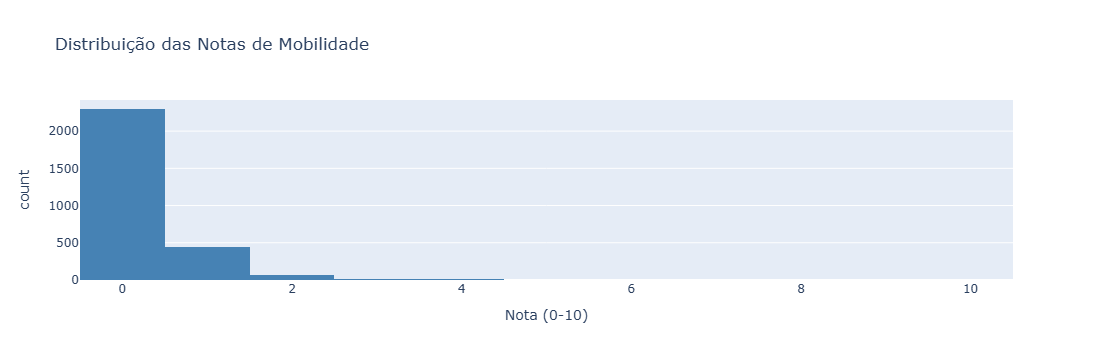

In [18]:
# ── HISTOGRAMA DA DISTRIBUIÇÃO DAS NOTAS ─────────────────────────────────────
fig2 = px.histogram(
    df,
    x='nota_dimensao',
    nbins=20,
    title='Distribuição das Notas de Mobilidade',
    labels={'nota_dimensao': 'Nota (0-10)', 'count': 'Nº de Bairros'},
    color_discrete_sequence=['steelblue']
)
fig2.show()

In [20]:
# ── RESUMO FINAL ──────────────────────────────────────────────────────────────
print('=' * 50)
print('RESUMO — DIMENSÃO MOBILIDADE URBANA')
print('=' * 50)
print(f'Total de bairros analisados : {len(df)}')
print(f'Nota média                  : {df["nota_dimensao"].mean():.2f}')
print(f'Nota máxima                 : {df["nota_dimensao"].max():.2f} ({df.loc[df["nota_dimensao"].idxmax(), "bairro"]})')
print(f'Nota mínima                 : {df["nota_dimensao"].min():.2f} ({df.loc[df["nota_dimensao"].idxmin(), "bairro"]})')
print(f'Bairros nota < 3 (ruim)     : {(df["nota_dimensao"] < 3).sum()}')
print(f'Bairros nota > 7 (bom)      : {(df["nota_dimensao"] > 7).sum()}')
print('=' * 50)
print()
print('Arquivos gerados:')
print(f'  data/processed/mobilidade_por_bairro.csv  ← entrega para Rodrigo')
print(f'  data/processed/recife_mobilidade.geojson  ← mapa completo')
print(f'  data/final/mapa_mobilidade.png            ← imagem estática')
print(f'  data/final/mapa_mobilidade_interativo.html ← mapa Folium')
print(f'  data/final/grafico_mobilidade.html        ← gráfico Plotly')

RESUMO — DIMENSÃO MOBILIDADE URBANA
Total de bairros analisados : 2835
Nota média                  : 0.34
Nota máxima                 : 10.00 (2611606092.0)
Nota mínima                 : 0.00 (2611606001.0)
Bairros nota < 3 (ruim)     : 2817
Bairros nota > 7 (bom)      : 1

Arquivos gerados:
  data/processed/mobilidade_por_bairro.csv  ← entrega para Rodrigo
  data/processed/recife_mobilidade.geojson  ← mapa completo
  data/final/mapa_mobilidade.png            ← imagem estática
  data/final/mapa_mobilidade_interativo.html ← mapa Folium
  data/final/grafico_mobilidade.html        ← gráfico Plotly
